# CardioPredict — Heart Disease Prediction

An end-to-end machine learning project for **binary heart disease classification** using the UCI Heart Disease dataset.

### Project workflow
1. Load and understand the dataset
2. Clean invalid values and define the binary target
3. Split data without leakage
4. Build a preprocessing pipeline
5. Compare multiple classification models
6. Tune Gradient Boosting with 5-fold cross-validation
7. Evaluate the final model on a held-out test set
8. Inspect feature importance
9. Save and verify the final model

> **Important:** This is an educational machine-learning project. It is not a medical diagnostic system.

## 1. Import libraries

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Load the dataset

In [2]:
df = pd.read_csv("heart_disease_uci.csv")

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3. Understand the dataset

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_count"))

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data types:


,dtype
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64



Missing values:


,missing_count
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [4]:
print("Original target distribution:")
display(
    df["num"]
    .value_counts()
    .sort_index()
    .rename_axis("num")
    .to_frame("count")
)

print("Original target percentages:")
display(
    (df["num"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .rename_axis("num")
    .to_frame("percentage")
)

Original target distribution:


,count
num,
0,411
1,265
2,109
3,107
4,28


Original target percentages:


,percentage
num,
0,44.67
1,28.80
2,11.85
3,11.63
4,3.04


## 4. Create the binary target

The original `num` column contains multiple disease severity levels:

- `0` → no disease
- `1–4` → presence of heart disease

For this project, the task is binary classification:

`target = 0` → no heart disease  
`target = 1` → heart disease

In [5]:
df["target"] = (df["num"] > 0).astype(int)

target_counts = df["target"].value_counts().sort_index()
print("Binary target distribution:")
display(target_counts.rename_axis("target").to_frame("count"))

Binary target distribution:


,count
target,
0,411
1,509


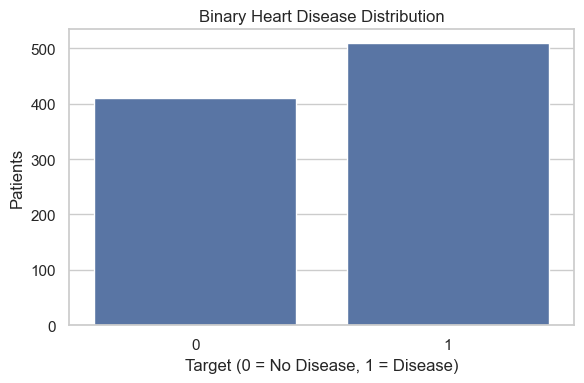

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Binary Heart Disease Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Patients")
plt.tight_layout()
plt.show()

## 5. Explore categorical and numerical features

In [7]:
categorical_columns = [
    "sex", "dataset", "cp", "fbs",
    "restecg", "exang", "slope", "thal"
]

for column in categorical_columns:
    print(f"\n{column}")
    display(df[column].value_counts(dropna=False).to_frame("count"))


sex


,count
sex,
Male,726
Female,194



dataset


,count
dataset,
Cleveland,304
Hungary,293
VA Long Beach,200
Switzerland,123



cp


...

,count
exang,
False,528
True,337
NaN,55



slope


,count
slope,
flat,345
NaN,309
upsloping,203
downsloping,63



thal


,count
thal,
NaN,486
normal,196
reversable defect,192
fixed defect,46


In [8]:
numerical_columns = [
    "age", "trestbps", "chol", "thalch", "oldpeak", "ca"
]

display(df[numerical_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.510870,9.424685,28.0,47.0,54.0,60.0,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.0,130.0,140.0,200.0
chol,890.0,199.130337,110.780810,0.0,175.0,223.0,268.0,603.0
thalch,865.0,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.0,0.5,1.5,6.2
ca,309.0,0.676375,0.935653,0.0,0.0,0.0,1.0,3.0


## 6. Data quality checks

Two measurements contain values of `0` that are not physiologically meaningful for this dataset:

- `trestbps = 0`
- `chol = 0`

These are treated as missing values and handled later by the preprocessing pipeline.

The `dataset` column is also removed from modeling because its source-specific target distribution can introduce dataset/source leakage.

In [9]:
print("Invalid zero values:")
print("trestbps == 0:", (df["trestbps"] == 0).sum())
print("chol == 0:", (df["chol"] == 0).sum())

print("\nMissing values before cleaning:")
display(df.isnull().sum().to_frame("missing_count"))

Invalid zero values:
trestbps == 0: 1
chol == 0: 172

Missing values before cleaning:


,missing_count
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [10]:
data = df.copy()

# Remove identifier, original multi-class target, and dataset source.
data = data.drop(columns=["id", "num", "dataset"])

# Convert invalid zero measurements to missing values.
data["trestbps"] = data["trestbps"].replace(0, np.nan)
data["chol"] = data["chol"].replace(0, np.nan)

X = data.drop(columns=["target"])
y = data["target"]

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values after cleaning:")
display(X.isnull().sum().to_frame("missing_count"))

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Feature shape: (920, 13)
Target shape: (920,)

Missing values after cleaning:


,missing_count
age,0
sex,0
cp,0
trestbps,60
chol,202
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62


## 7. Train/test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
display(y_train.value_counts().sort_index().rename_axis("target").to_frame("count"))

print("\nTesting target distribution:")
display(y_test.value_counts().sort_index().rename_axis("target").to_frame("count"))

Training samples: 736
Testing samples: 184

Training target distribution:


,count
target,
0,329
1,407



Testing target distribution:


,count
target,
0,82
1,102


## 8. Build a leakage-safe preprocessing pipeline

Numerical features:
- Median imputation
- Standard scaling

Categorical features:
- Most-frequent imputation
- One-hot encoding

The preprocessing is placed **inside the scikit-learn pipeline**, so transformations are learned only from the training data.

In [12]:
numerical_features = [
    "age", "trestbps", "chol", "thalch", "oldpeak", "ca"
]

categorical_features = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "thal"
]

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features),
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 9. Compare baseline models

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
    "SVM": SVC(
        probability=True,
        random_state=42
    ),
}

trained_models = {}
results = []

for name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8207,0.8053,0.8922,0.8465,0.9057
1,SVM,0.8152,0.8036,0.8824,0.8411,0.8975
2,Logistic Regression,0.8098,0.8190,0.8431,0.8309,0.8895
3,Random Forest,0.7935,0.7963,0.8431,0.8190,0.9003


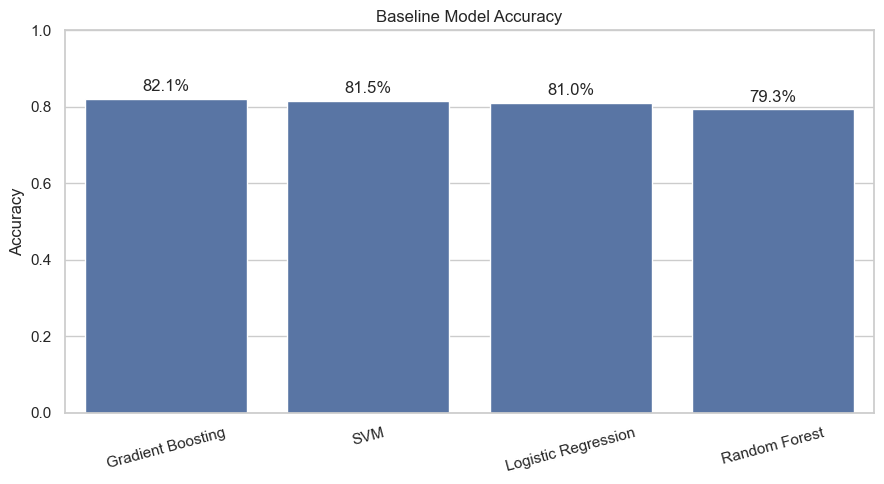

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.ylim(0, 1)
plt.title("Baseline Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("")
plt.xticks(rotation=15)

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(i, value + 0.02, f"{value:.1%}", ha="center")

plt.tight_layout()
plt.show()

## 10. Hyperparameter tuning — Gradient Boosting

Gradient Boosting was selected for further tuning.

`GridSearchCV` evaluates parameter combinations using **5-fold cross-validation** and optimizes **ROC-AUC** on the training data.

In [15]:
gradient_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42)),
])

param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    gradient_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print(f"\nBest cross-validation ROC-AUC: {grid_search.best_score_:.4f}")

Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_split': 5, 'model__n_estimators': 150}

Best cross-validation ROC-AUC: 0.8712


## 11. Evaluate the final tuned model

In [16]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
}

final_metrics_df = pd.DataFrame(
    [final_metrics],
    index=["Tuned Gradient Boosting"]
)

display(final_metrics_df.round(4))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Tuned Gradient Boosting,0.8261,0.8241,0.8725,0.8476,0.909


In [17]:
print("Classification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Disease", "Disease"]
))

Classification report:
              precision    recall  f1-score   support

  No Disease       0.83      0.77      0.80        82
     Disease       0.82      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



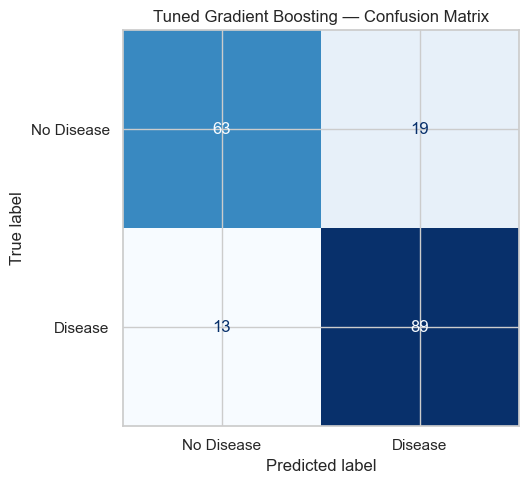

Confusion matrix:
[[63 19]
 [13 89]]


In [18]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
).plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Tuned Gradient Boosting — Confusion Matrix")
plt.tight_layout()
plt.show()

print("Confusion matrix:")
print(cm)

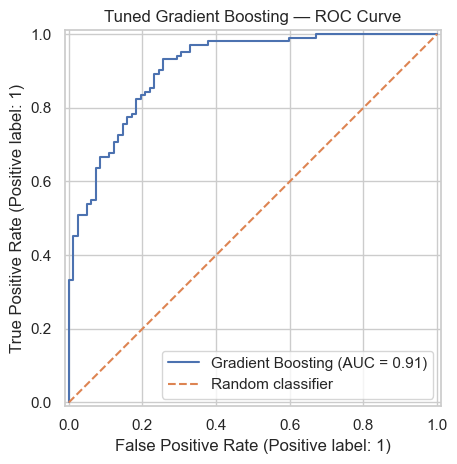

In [19]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("Tuned Gradient Boosting — ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Baseline vs tuned Gradient Boosting

In [20]:
baseline_gb = trained_models["Gradient Boosting"]

baseline_pred = baseline_gb.predict(X_test)
baseline_prob = baseline_gb.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Baseline Gradient Boosting": [
        accuracy_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred),
        recall_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred),
        roc_auc_score(y_test, baseline_prob),
    ],
    "Tuned Gradient Boosting": [
        final_metrics["Accuracy"],
        final_metrics["Precision"],
        final_metrics["Recall"],
        final_metrics["F1 Score"],
        final_metrics["ROC-AUC"],
    ],
})

display(comparison.round(4))

,Metric,Baseline Gradient Boosting,Tuned Gradient Boosting
0,Accuracy,0.8207,0.8261
1,Precision,0.8053,0.8241
2,Recall,0.8922,0.8725
3,F1 Score,0.8465,0.8476
4,ROC-AUC,0.9057,0.9090


## 13. Feature importance

In [21]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = best_model.named_steps[
    "model"
].feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(15))

,Feature,Importance
0,cat__cp_asymptomatic,0.320672
1,cat__exang_True,0.094373
2,num__age,0.094018
3,num__oldpeak,0.092523
4,num__thalch,0.077885
5,num__chol,0.056802
6,cat__cp_atypical angina,0.050799
7,cat__sex_Male,0.039498
8,cat__sex_Female,0.035107
9,cat__exang_False,0.029697


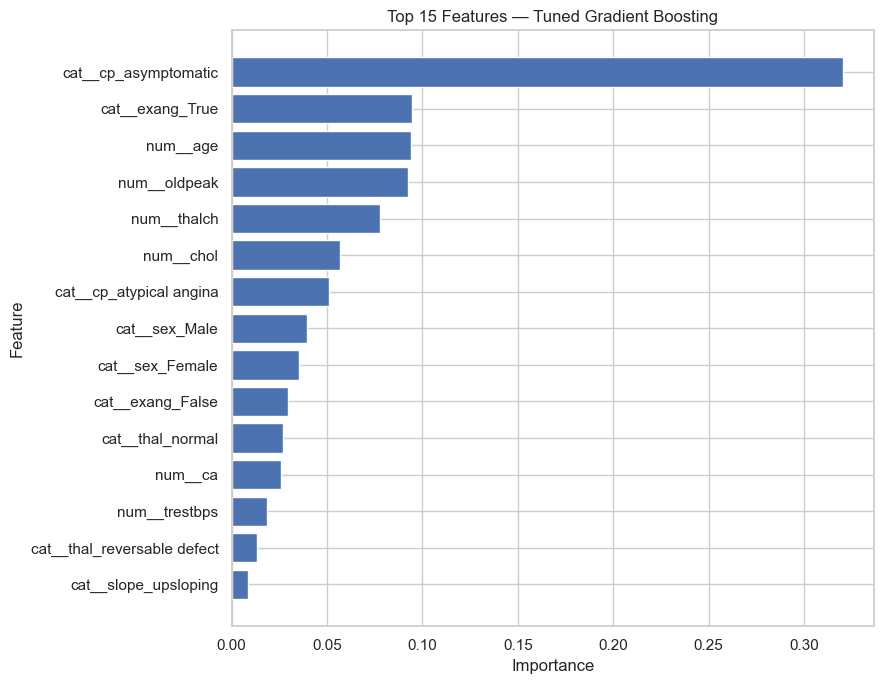

In [22]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(9, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

## 14. Save the final model

In [23]:
MODEL_PATH = "heart_disease_model.pkl"

joblib.dump(best_model, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")
print(f"Model exists: {os.path.exists(MODEL_PATH)}")
print(f"Model size: {os.path.getsize(MODEL_PATH) / 1024:.2f} KB")

Model saved to: heart_disease_model.pkl
Model exists: True
Model size: 174.53 KB


## 15. Verify the saved model

In [24]:
loaded_model = joblib.load(MODEL_PATH)

sample_patient = pd.DataFrame([{
    "age": 55,
    "sex": "Male",
    "cp": "asymptomatic",
    "trestbps": 130,
    "chol": 250,
    "fbs": False,
    "restecg": "normal",
    "thalch": 140,
    "exang": False,
    "oldpeak": 1.0,
    "slope": "flat",
    "ca": 0,
    "thal": "normal",
}])

prediction = loaded_model.predict(sample_patient)[0]
probability = loaded_model.predict_proba(sample_patient)[0, 1]

print("Sample patient prediction:", prediction)
print(f"Estimated probability: {probability:.2%}")

Sample patient prediction: 1
Estimated probability: 69.88%


In [25]:
sample_patient_2 = pd.DataFrame([{
    "age": 35,
    "sex": "Female",
    "cp": "atypical angina",
    "trestbps": 110,
    "chol": 180,
    "fbs": False,
    "restecg": "normal",
    "thalch": 175,
    "exang": False,
    "oldpeak": 0.0,
    "slope": "upsloping",
    "ca": 0,
    "thal": "normal",
}])

prediction_2 = loaded_model.predict(sample_patient_2)[0]
probability_2 = loaded_model.predict_proba(sample_patient_2)[0, 1]

print("Sample patient 2 prediction:", prediction_2)
print(f"Estimated probability: {probability_2:.2%}")

Sample patient 2 prediction: 0
Estimated probability: 2.15%


## 16. Environment verification

The Streamlit app uses the same scikit-learn and joblib versions used to create the saved model. Keeping these versions aligned prevents serialization compatibility errors.

In [26]:
import sklearn

print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
joblib: 1.4.2


## Final project summary

**Final model:** Gradient Boosting  
**Test accuracy:** approximately **82.6%**  
**ROC-AUC:** approximately **0.91**

The project demonstrates an end-to-end workflow: data cleaning → leakage-safe preprocessing → model comparison → hyperparameter tuning → evaluation → model persistence → Streamlit deployment.

> The reported test metrics are specific to this dataset and held-out split. They should not be interpreted as clinical performance.